In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

In [4]:
def load_image(path):
    image = Image.open(path).convert("RGB")
    image = transform(image).unsqueeze(0)
    return image.to(device)

In [6]:
content_path = "C:/Users/26911/Desktop/diffusion_style_project/data/content/content_001.jpg"
style_path = "C:/Users/26911/Desktop/diffusion_style_project/data/style/vangogh/style_001.jpg"

content = load_image(content_path)
style = load_image(style_path)

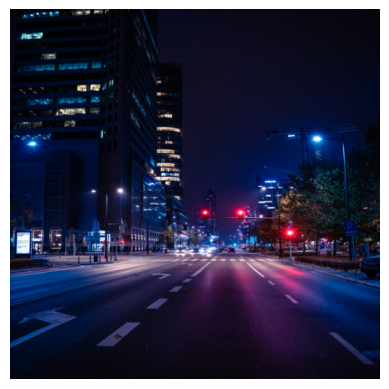

In [7]:
def show_image(tensor):
    image = tensor.cpu().clone().detach().squeeze(0)
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    plt.axis("off")

show_image(content)

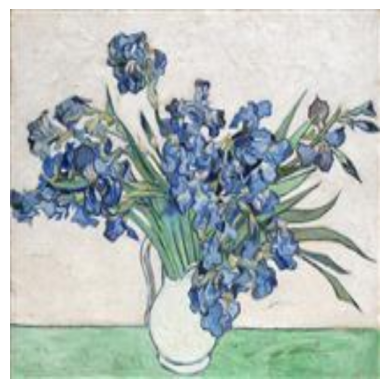

In [8]:
show_image(style)

In [9]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

D:\anaconda3\envs\diffusion\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\anaconda3\envs\diffusion\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\26911/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth
100%|███████████████████████████████████████████████████████████████████████████████| 548M/548M [00:35<00:00, 16.1MB/s]


In [10]:
def gram_matrix(x):
    b, c, h, w = x.size()
    x = x.view(c, h*w)
    return torch.mm(x, x.t())

In [11]:
generated = content.clone().requires_grad_(True).to(device)

In [12]:
optimizer = optim.Adam([generated], lr=0.02)

In [13]:
steps = 300

for step in range(steps):

    optimizer.zero_grad()

    gen_features = vgg(generated)
    content_features = vgg(content)
    style_features = vgg(style)

    content_loss = torch.mean((gen_features - content_features)**2)

    G = gram_matrix(gen_features)
    A = gram_matrix(style_features)

    style_loss = torch.mean((G - A)**2)

    total_loss = content_loss + 1e6 * style_loss

    total_loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(step, total_loss.item())

0 404872960.0
50 6594919.5
100 4051651.25
150 3879414.25
200 2644377.5
250 3161990.75


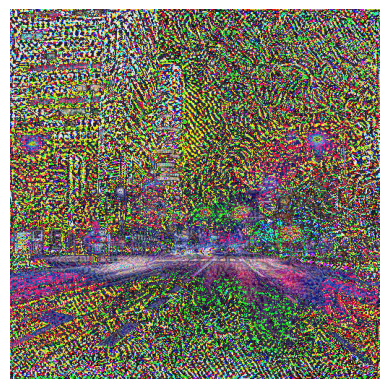

In [14]:
show_image(generated)

In [15]:
result = generated.cpu().clone().detach().squeeze(0)
result = transforms.ToPILImage()(result)

result.save("C:/Users/26911/Desktop/diffusion_style_project/results/cnn_vangogh.png")